# Train segmentation model

## Training the segmentation head from embeddings

In this notebook you can train the segmentation model using pre-computed embeddings via LightningCLI using configurations in `configs/train_embedding_classifier.yaml`. Modify the batch size, learning rate, and other hyperparameters in the configuration file as needed.

This notebook uses a CSV logger by default for training, validation and test results. A [WandB logger](https://lightning.ai/docs/pytorch/stable/extensions/generated/lightning.pytorch.loggers.WandbLogger.html#lightning.pytorch.loggers.WandbLogger) can also be used. If you prefer the latter, please switch the loggers and update the entity of the WandB logger configuration in `configs/train_embedding_classifier.yaml`.


In [1]:
import os
from pathlib import Path

def find_project_root(marker='claymodel'):
    current = Path.cwd()
    for path in [current] + list(current.parents):
        if (path / marker).exists():
            return path
    raise FileNotFoundError(f"Project root not found")

os.chdir(find_project_root())

In [2]:
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.cli import LightningArgumentParser, instantiate_class
import lightning.pytorch as L

from claymodel.finetune.boundary_detection.embedding_ai4b_classifier import EmbeddingClassifierAI4B
from claymodel.finetune.boundary_detection.embedding_datamodule_ai4b import EmbeddingDataModuleAI4B

from datetime import datetime

seed_everything(42)  # your seed here

def Train_segmentation_from_embeddings(config_path, test_after_training=False):
    
    objects = ["callbacks", "logger", "plugins"]

    # Create argument parser similar to LightningCLI
    parser = LightningArgumentParser()
    parser.add_lightning_class_args(EmbeddingClassifierAI4B, "model")
    parser.add_lightning_class_args(EmbeddingDataModuleAI4B, "data")
    parser.add_lightning_class_args(Trainer, "trainer")
    
    # Parse the config file
    config = parser.parse_path(config_path)

    trainer_config = dict(config["trainer"])
    
    # Instantiate objects
    for object in objects:
        if object in trainer_config and trainer_config[object]:
            callbacks = []
            for callback_config in trainer_config[object]:
                if hasattr(callback_config, 'class_path') and hasattr(callback_config, 'init_args'):
                    
                    if object == "logger":
                        if callback_config.class_path == "lightning.pytorch.loggers.CSVLogger":
                            callback_config.init_args['version'] = datetime.now().strftime("%Y%m%d_%H%M%S")
                        elif callback_config.class_path == "lightning.pytorch.loggers.WandbLogger":
                            callback_config.init_args['name'] = "AI4B_model_" + datetime.now().strftime("%Y%m%d_%H%M%S")

                    if object == "callbacks" and callback_config.class_path == "lightning.pytorch.callbacks.ModelCheckpoint":
                        callback_config.init_args['dirpath'] = os.path.join(callback_config.init_args['dirpath'], datetime.now().strftime("%Y%m%d_%H%M%S"))
                    callback = instantiate_class((), callback_config)
                    callbacks.append(callback)        

                elif isinstance(callback_config, dict) and "class_path" in callback_config:
                    # This is a dictionary configuration
                    callback = instantiate_class((), callback_config)
                    callbacks.append(callback)
                else:
                    # Already an instantiated callback
                    callbacks.append(callback_config)
            
            trainer_config[object] = callbacks

    # Create instances
    model = EmbeddingClassifierAI4B(**config["model"])
    datamodule = EmbeddingDataModuleAI4B(**config["data"])
    trainer = Trainer(**trainer_config)

        # Log the full model config to Weights & Biases, if enabled
    try:
        model_config = dict(config["model"])  # ensure standard dict
        for logger in trainer.loggers:
            if isinstance(logger, L.pytorch.loggers.WandbLogger):
                run = logger.experiment  # wandb.Run
                if run is not None:
                    run.config.update({"model": model_config}, allow_val_change=True)
            elif isinstance(logger, L.pytorch.loggers.CSVLogger):
                # Store under 'model' key in hparams.yaml within the CSV log dir
                logger.log_hyperparams({"model": model_config})
    except Exception:
        # Be robust if loggers differ or dependencies are missing
        pass

    result = trainer.fit(model, datamodule)
    if test_after_training:
        result = trainer.test(model, datamodule)
        #print(model.confusion_matrix)

    print("Results:", result)
    
    return model, datamodule, trainer, result

Seed set to 42


## Training the model

Run the training process. The model will be trained using the configuration specified in `configs/train_embedding_classifier.yaml`. Set `test_after_training=True` to also run evaluation on the test set after training.


Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


🏗️  EmbeddingClassifierAI4B initialized:
   Input: 1024D embeddings, 8x8 patches
   Output: Two products of size (256, 256)
   Fusion: early fusion
   ASPP: False, Residual: True


wandb: Currently logged in as: ignaciomasari (ignaciomasari-eodc) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/home/ignacio/Code/Clay-foundation/model/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:231: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name    | Type                           | Params | Mode 
-------------------------------------------------------------------
0 | model   | TemporalFusionSegmentationHead | 37.7 M | train
1 | OA      | BinaryAccuracy                 | 0      | train
2 | loss_fn | FocalLoss                      | 0      | train
3 | iou     | BinaryJaccardIndex             | 0      | train
4 | f1      | BinaryF1Score                  | 0      | train
-------------------------------------------------------------------
37.7 M    Trainable params
0         Non-trainable params
37.7 M    Total params
150.893   Total estimated model params size (MB)
48        Modules in train mode
0         Modules in eval mode
/home/ignacio/Code/Clay-f

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 0, global step 13: 'val/f1' reached 0.60780 (best 0.60780), saving model to '/home/ignacio/Code/Clay-foundation/model/checkpoints/boundary_embeddings/20251020_154018/embedding-boundary_epoch-00_val-f1-0.6078.ckpt' as top 1
`Trainer.fit` stopped: `max_epochs=1` reached.


Testing: |          | 0/? [00:00<?, ?it/s]

/home/ignacio/Code/Clay-foundation/model/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 4. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 test/boundary_f1_epoch     0.7661086320877075
 test/boundary_iou_epoch    0.6275595426559448
test/boundary_loss_epoch    0.11113935708999634
 test/boundary_oa_epoch     0.7463842630386353
      test/f1_epoch         0.6146916747093201
   test/field_f1_epoch      0.46327468752861023
  test/field_iou_epoch      0.3022282123565674
  test/field_loss_epoch     0.09096700698137283
   test/field_oa_epoch       0.610361635684967
     test/iou_epoch         0.4648938775062561
     test/loss_epoch        0.20210634171962738
      test/oa_epoch         0.6783729791641235
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Results: [{'test/loss_epo

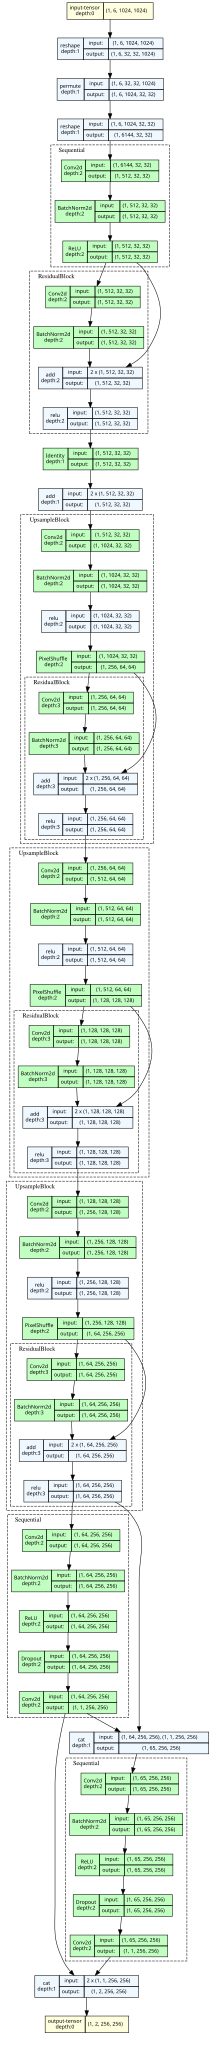

In [3]:
CONFIG_PATH = "configs/train_embedding_boundary_detection.yaml"
model, datamodule, trainer, _ = Train_segmentation_from_embeddings(CONFIG_PATH, True)
model.draw_graph().visual_graph

In [4]:
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import lightning as L


def count_confusion_pixels(
    model: L.LightningModule,
    datamodule: L.LightningDataModule,
    trainer: L.Trainer,
    split: str = "test",
    print_results: bool = False,

):
    """
    Count all pixels across entire dataset split for confusion matrix analysis.
    
    Counts:
    - Exclusion pixels (ignored areas)
    - TN (True Negative): correctly predicted non-flood
    - TP (True Positive): correctly predicted flood
    - FN (False Negative): missed flood
    - FP (False Positive): incorrectly predicted flood
    
    Args:
        model: Lightning model
        datamodule: Lightning datamodule with the dataset
        trainer: Lightning trainer
        split: Dataset split ('train', 'val', or 'test')
        print_results: Whether to print detailed results
    
    Returns:
        dict: Pixel counts for each category and computed metrics
    """
    # Get appropriate dataloader
    if split == "train":
        dataloader = datamodule.train_dataloader()
    elif split == "val":
        dataloader = datamodule.val_dataloader()
    elif split == "test":
        dataloader = datamodule.test_dataloader()
    else:
        raise ValueError("split must be 'train', 'val' or 'test'")

    # Initialize counters
    counts = {
        "TN_b": 0,
        "TP_b": 0,
        "FN_b": 0,
        "FP_b": 0,
        "TN_f": 0,
        "TP_f": 0,
        "FN_f": 0,
        "FP_f": 0,
        "total_pixels": 0,
    }

    # Set model to eval mode
    model.eval()
    
    # Move model to appropriate device
    device = trainer.strategy.root_device if hasattr(trainer.strategy, 'root_device') else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    print(f"Processing {len(dataloader)} batches from {split} split...")

    # Process all batches
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Processing {split} chips"):
            # Get batch data
            embedding = batch["embedding"].to(device)
            labels = batch["label"]  # Keep on CPU for efficiency            

            # Forward pass
            batch_input = {
                "embedding": embedding,
            }
            logits = model(batch_input)
            
            # Get predictions
            probs = torch.sigmoid(logits).squeeze(1)  # [B, H, W]
            pred_mask = (probs > 0.5).cpu().numpy().astype(np.uint8)
            
            # Convert to numpy for counting
            labels = labels.cpu().numpy().astype(np.uint8)

            boundary_labels = labels[: ,0 ,: ,:]  # Boundary labels
            field_labels = labels[:, 1, :, :]    # Field labels

            boundary_pred = pred_mask[:, 0, :, :]  # Boundary predictions
            field_pred = pred_mask[:, 1, :, :]      # Field predictions

            # Process each item in batch
            # batch_size = labels.shape[0]
            # for i in range(batch_size):
            #     label = labels[i]
            #     pred = pred_mask[i]
                
            # Count pixels
            total_pixels = labels.size / 2
            counts["total_pixels"] = total_pixels
        
            
            # Count confusion matrix elements (only on valid pixels)
            counts["TN_b"] = np.sum((boundary_labels == 0) & (boundary_pred == 0))
            counts["TP_b"] = np.sum((boundary_labels == 1) & (boundary_pred == 1))
            counts["FN_b"] = np.sum((boundary_labels == 1) & (boundary_pred == 0))
            counts["FP_b"] = np.sum((boundary_labels == 0) & (boundary_pred == 1))

            counts["TN_f"] = np.sum((field_labels == 0) & (field_pred == 0))
            counts["TP_f"] = np.sum((field_labels == 1) & (field_pred == 1))
            counts["FN_f"] = np.sum((field_labels == 1) & (field_pred == 0))
            counts["FP_f"] = np.sum((field_labels == 0) & (field_pred == 1))



    # Calculate metrics
    # confusion_sum = counts['TN'] + counts['TP'] + counts['FN'] + counts['FP']
    
    # accuracy = (counts['TP'] + counts['TN']) / counts['total_pixels'] if counts['total_pixels'] > 0 else 0
    # precision = counts['TP'] / (counts['TP'] + counts['FP']) if (counts['TP'] + counts['FP']) > 0 else 0
    # recall = counts['TP'] / (counts['TP'] + counts['FN']) if (counts['TP'] + counts['FN']) > 0 else 0
    # f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    # iou = counts['TP'] / (counts['TP'] + counts['FP'] + counts['FN']) if (counts['TP'] + counts['FP'] + counts['FN']) > 0 else 0
    
    # # Add metrics to return dict
    # counts['metrics'] = {
    #     'accuracy': accuracy,
    #     'precision': precision,
    #     'recall': recall,
    #     'f1': f1,
    #     'iou': iou,
    # }
    
    accuracy_b = (counts['TP_b'] + counts['TN_b']) / counts['total_pixels'] if counts['total_pixels'] > 0 else 0
    precision_b = counts['TP_b'] / (counts['TP_b'] + counts['FP_b']) if (counts['TP_b'] + counts['FP_b']) > 0 else 0
    recall_b = counts['TP_b'] / (counts['TP_b'] + counts['FN_b']) if (counts['TP_b'] + counts['FN_b']) > 0 else 0
    f1_b = 2 * (precision_b * recall_b) / (precision_b + recall_b) if (precision_b + recall_b) > 0 else 0
    iou_b = counts['TP_b'] / (counts['TP_b'] + counts['FP_b'] + counts['FN_b']) if (counts['TP_b'] + counts['FP_b'] + counts['FN_b']) > 0 else 0

    accuracy_f = (counts['TP_f'] + counts['TN_f']) / counts['total_pixels'] if counts['total_pixels'] > 0 else 0
    precision_f = counts['TP_f'] / (counts['TP_f'] + counts['FP_f']) if (counts['TP_f'] + counts['FP_f']) > 0 else 0
    recall_f = counts['TP_f'] / (counts['TP_f'] + counts['FN_f']) if (counts['TP_f'] + counts['FN_f']) > 0 else 0
    f1_f = 2 * (precision_f * recall_f) / (precision_f + recall_f) if (precision_f + recall_f) > 0 else 0
    iou_f = counts['TP_f'] / (counts['TP_f'] + counts['FP_f'] + counts['FN_f']) if (counts['TP_f'] + counts['FP_f'] + counts['FN_f']) > 0 else 0

    counts['metrics'] = {
        'boundary_accuracy': accuracy_b,
        'boundary_precision': precision_b,
        'boundary_recall': recall_b,
        'boundary_f1': f1_b,
        'boundary_iou': iou_b,
        'field_accuracy': accuracy_f,
        'field_precision': precision_f,
        'field_recall': recall_f,
        'field_f1': f1_f,
        'field_iou': iou_f,
    }
    
    if print_results:
        print_confusion_results(counts, split, len(dataloader))
    
    return counts


def print_confusion_results(counts, split, num_batches):
    """Helper function to print formatted results."""
    metrics = counts['metrics']
    
    print("\n" + "="*60)
    print(f"CONFUSION MATRIX PIXEL COUNTS - {split.upper()} SPLIT")
    print("="*60)
    print(f"\nTotal batches processed: {num_batches}")
    print(f"Total pixels: {counts['total_pixels']:,}")
    
    print(f"\n{'─'*60}")
    print("CONFUSION MATRIX (boundaries):")
    print(f"{'─'*60}")
    print(f"True Negatives  (TN): {counts['TN_b']:,}")
    print(f"True Positives  (TP): {counts['TP_b']:,}")
    print(f"False Negatives (FN): {counts['FN_b']:,}")
    print(f"False Positives (FP): {counts['FP_b']:,}")

    print(f"\n{'─'*60}")
    print("METRICS (boundaries):")
    print(f"{'─'*60}")
    print(f"Overall Accuracy: {metrics['boundary_accuracy']:.4f} ({100*metrics['boundary_accuracy']:.2f}%)")
    print(f"Precision:        {metrics['boundary_precision']:.4f} ({100*metrics['boundary_precision']:.2f}%)")
    print(f"Recall:           {metrics['boundary_recall']:.4f} ({100*metrics['boundary_recall']:.2f}%)")
    print(f"F1 Score:         {metrics['boundary_f1']:.4f} ({100*metrics['boundary_f1']:.2f}%)")
    print(f"IoU (Jaccard):    {metrics['boundary_iou']:.4f} ({100*metrics['boundary_iou']:.2f}%)")        

    print(f"\n{'─'*60}")
    print("CONFUSION MATRIX (fields):")
    print(f"{'─'*60}")
    print(f"True Negatives  (TN): {counts['TN_f']:,}")
    print(f"True Positives  (TP): {counts['TP_f']:,}")
    print(f"False Negatives (FN): {counts['FN_f']:,}")
    print(f"False Positives (FP): {counts['FP_f']:,}")

    print(f"\n{'─'*60}")
    print("METRICS (fields):")
    print(f"{'─'*60}")
    print(f"Overall Accuracy: {metrics['field_accuracy']:.4f} ({100*metrics['field_accuracy']:.2f}%)")
    print(f"Precision:        {metrics['field_precision']:.4f} ({100*metrics['field_precision']:.2f}%)")
    print(f"Recall:           {metrics['field_recall']:.4f} ({100*metrics['field_recall']:.2f}%)")
    print(f"F1 Score:         {metrics['field_f1']:.4f} ({100*metrics['field_f1']:.2f}%)")
    print(f"IoU (Jaccard):    {metrics['field_iou']:.4f} ({100*metrics['field_iou']:.2f}%)")  
        
    print("="*60 + "\n")

Processing 3 batches from val split...


Processing val chips:   0%|          | 0/3 [00:00<?, ?it/s]/home/ignacio/Code/Clay-foundation/model/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Processing val chips: 100%|██████████| 3/3 [00:24<00:00,  8.13s/it]



Confusion Matrix for val set Boundaries:


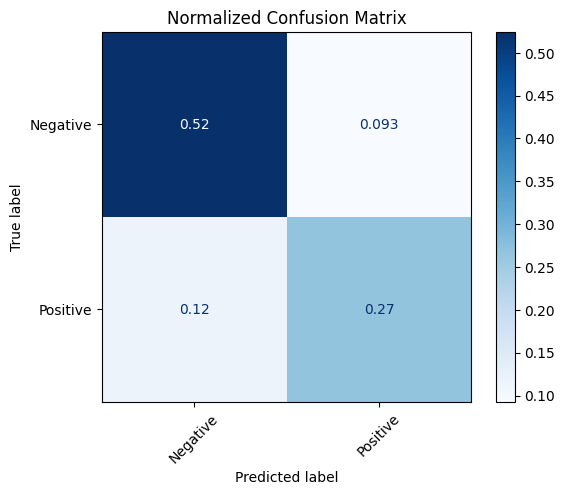


Confusion Matrix for val set Fields:


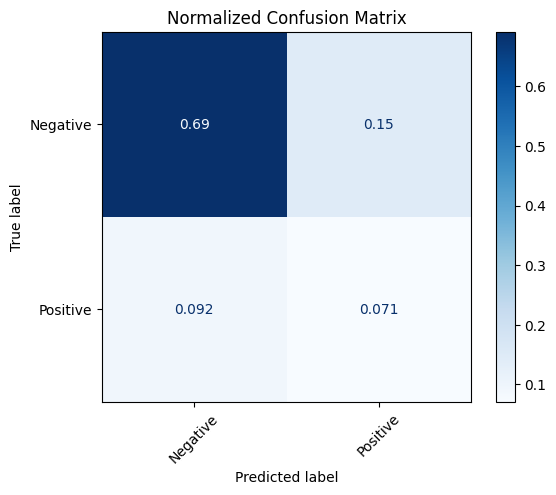

Processing 7 batches from test split...


Processing test chips:   0%|          | 0/7 [00:00<?, ?it/s]/home/ignacio/Code/Clay-foundation/model/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Processing test chips: 100%|██████████| 7/7 [00:57<00:00,  8.25s/it]



Confusion Matrix for test set Boundaries:


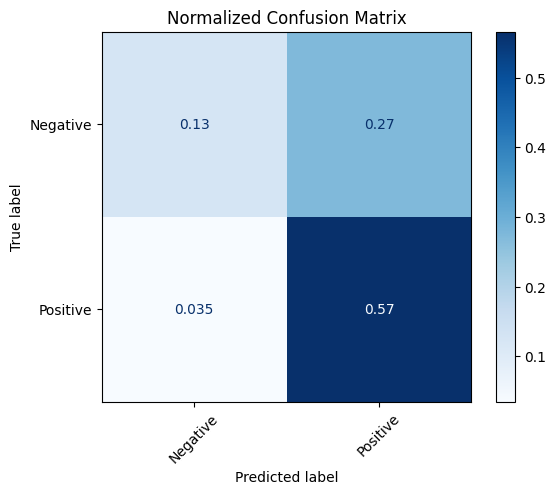


Confusion Matrix for test set Fields:


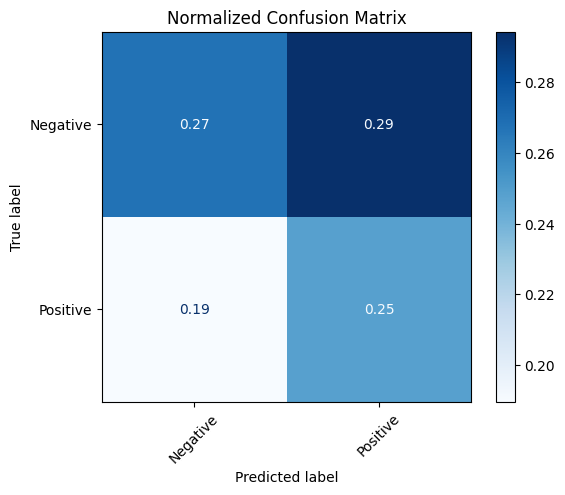

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

for split in ["val", "test"]:

    results=count_confusion_pixels(model, datamodule, trainer, split=split, print_results=False)
    
    print(f"\nConfusion Matrix for {split} set Boundaries:")
    cm = np.zeros((2,2), dtype=np.int64)

    cm[0,0] = results["TN_b"]
    cm[1,1] = results["TP_b"]
    cm[1,0] = results["FN_b"]
    cm[0,1] = results["FP_b"]
    cm_normalized = cm / results["total_pixels"]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title('Normalized Confusion Matrix')
    plt.show()

    print(f"\nConfusion Matrix for {split} set Fields:")
    cm = np.zeros((2,2), dtype=np.int64)
    cm[0,0] = results["TN_f"]
    cm[1,1] = results["TP_f"]
    cm[1,0] = results["FN_f"]
    cm[0,1] = results["FP_f"]
    cm_normalized = cm / results["total_pixels"]

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title('Normalized Confusion Matrix')
    plt.show()

In [6]:
import random
import yaml
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from pathlib import Path
import rasterio as rio
import xarray as xr


def plot_random_n_chips_overlapped(model, config_path_yaml, n: int = 5, split: str = "test"):
    """
    Visualize random chips for the GFM setup using paired pre/post embeddings and binary flood labels.

    Shows: pre SIG0, post SIG0, and confusion matrix overlay where:
    - TN (True Negative): Black (K)
    - TP (True Positive): White (W)
    - FP (False Positive): Green (G)
    - FN (False Negative): Blue (B)
    - Exclusion: Red (R)
    """
    with open(config_path_yaml, "r") as f:
        config_dict = yaml.safe_load(f)

    if split == "train":
        embedding_path = Path(config_dict["data"]["train_embedd_dir"])
        labels_path = Path(config_dict["data"]["train_label_dir"])
    elif split == "val":
        embedding_path = Path(config_dict["data"]["val_embedd_dir"])
        labels_path = Path(config_dict["data"]["val_label_dir"]) 
    elif split == "test":
        embedding_path = Path(config_dict["data"]["test_embedd_dir"])
        labels_path = Path(config_dict["data"]["test_label_dir"]) 
    else:
        raise ValueError("split must be 'train', 'val' or 'test'")

    chips_path = embedding_path.parent

    embed_files = [p.name for p in embedding_path.glob("*.npy")]
    
    if len(embed_files) == 0:
        raise RuntimeError(f"No paired embeddings found in {embedding_path}")

    if n > len(embed_files):
        raise ValueError(
            f"n ({n}) is greater than the number of available pairs ({len(embed_files)})"
        )

    selected = random.sample(embed_files, n)

    model.eval()

    # Create figure with 3 columns: Pre, Post, Overlay
    _, axs = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axs = np.expand_dims(axs, axis=0)

    # Define colormap: 0=TN(Black), 1=TP(White), 2=FP(Green), 3=FN(Blue)
    colors = ['black', 'white', 'green', 'blue']
    cmap = ListedColormap(colors)

    for row_idx, embed_name in enumerate(selected):

        embedding_full_path = embedding_path / embed_name
        chip_idx = embed_name.split("_", 3)[1]                    

        embedding = np.load(embedding_full_path).astype(np.float32)        

        def find_first(pattern):
            matches = list((labels_path).glob(pattern))
            if len(matches) == 0:
                raise FileNotFoundError(f"No file matching {pattern} in {labels_path}")
            return matches[0]

        lbl_path = find_first(f"*_{chip_idx}_*.tif")        
        with rio.open(lbl_path) as src:
            label = src.read().astype(np.uint8)        

        # Load corresponding raw chip images
        chip_files = sorted(list((chips_path).glob(f"*_{chip_idx}_*.nc")))
        if len(chip_files) == 1:
            ds = xr.open_dataset(chip_files[0], engine='netcdf4')
            img = np.array([ds[d].values for d in ["B4", "B3", "B2"]]).astype(np.float32)
        img_rgb = img[:,0,...].copy().squeeze()  # Take first timestamp
        img_rgb = np.swapaxes(img_rgb, 0, -1)
        img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())
        img_rgb = np.clip(img_rgb, 0, 1)
            
        with torch.no_grad():
            batch = {
                "embedding": torch.from_numpy(embedding).unsqueeze(0),
            }
            
            device = next(model.parameters()).device
            batch = {k: v.to(device) for k, v in batch.items()}
            
            logits = model(batch)
            probs = torch.sigmoid(logits).squeeze(0).squeeze(0).cpu().numpy()
            pred_mask = (probs > 0.5).astype(np.uint8)   
            
        if img_rgb is not None:
            axs[row_idx, 0].imshow(img_rgb)
            axs[row_idx, 0].set_title("RGB March")

        overlay_b = np.zeros_like(label[0,...], dtype=np.uint8)
        overlay_b[(label[0,...] == 1) & (pred_mask[0,...] == 1)] = 1        
        overlay_b[(label[0,...] == 0) & (pred_mask[0,...] == 1)] = 2        
        overlay_b[(label[0,...] == 1) & (pred_mask[0,...] == 0)] = 3

        axs[row_idx, 1].imshow(overlay_b, cmap=cmap, vmin=0, vmax=3)
        axs[row_idx, 1].set_title("Boundaries")

        overlay_f = np.zeros_like(label[1,...], dtype=np.uint8)
        overlay_f[(label[1,...] == 1) & (pred_mask[1,...] == 1)] = 1        
        overlay_f[(label[1,...] == 0) & (pred_mask[1,...] == 1)] = 2        
        overlay_f[(label[1,...] == 1) & (pred_mask[1,...] == 0)] = 3

        axs[row_idx, 2].imshow(overlay_f, cmap=cmap, vmin=0, vmax=3)
        axs[row_idx, 2].set_title("Fields (TN:K, TP:W, FP:G, FN:B)")

        for c in range(3):
            axs[row_idx, c].axis("off")

    plt.tight_layout()
    plt.show()

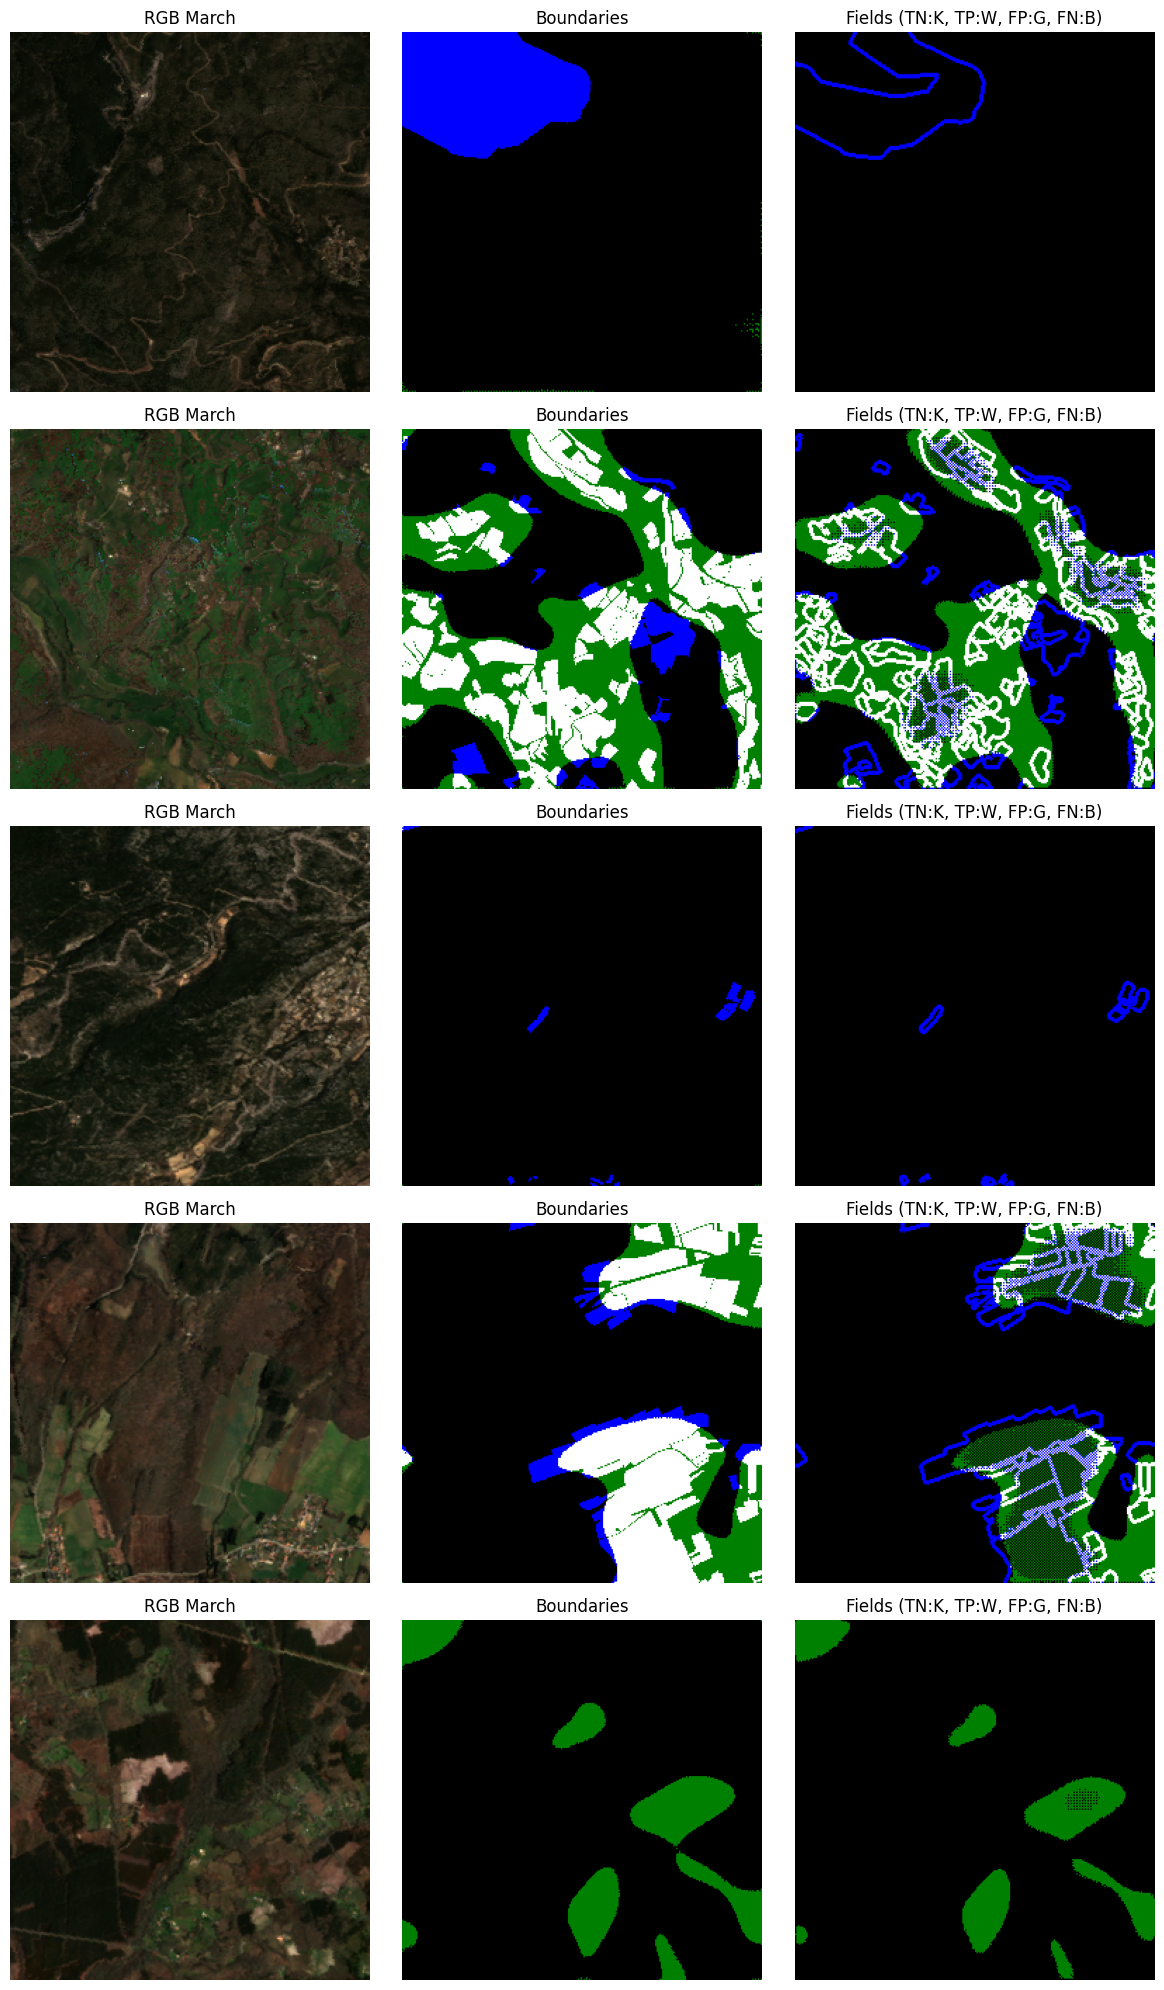

In [7]:
# Visualize random test samples
plot_random_n_chips_overlapped(model, config_path_yaml=CONFIG_PATH, n=5, split="train")


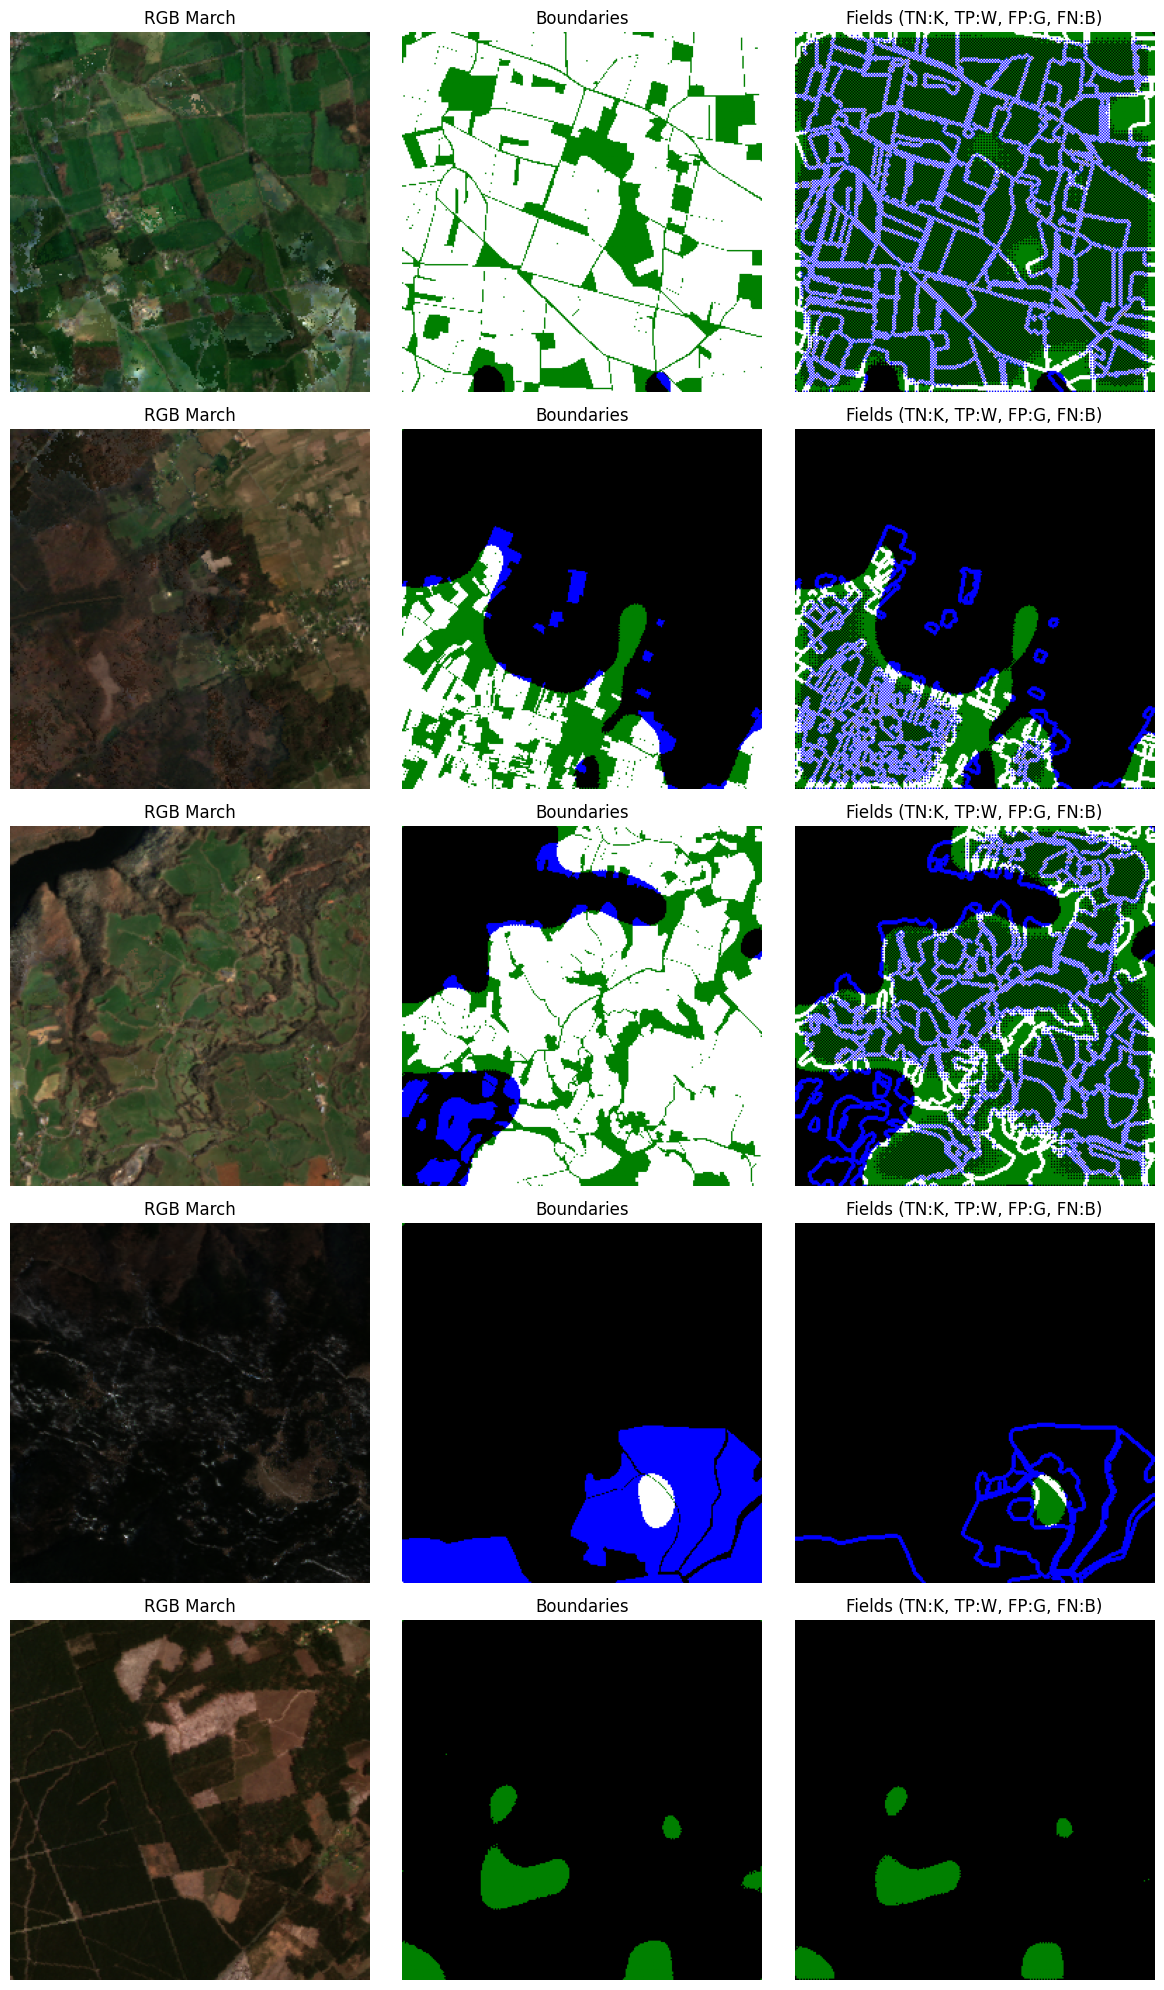

In [8]:
# Visualize random validation samples
plot_random_n_chips_overlapped(model, config_path_yaml=CONFIG_PATH, n=5, split="val")

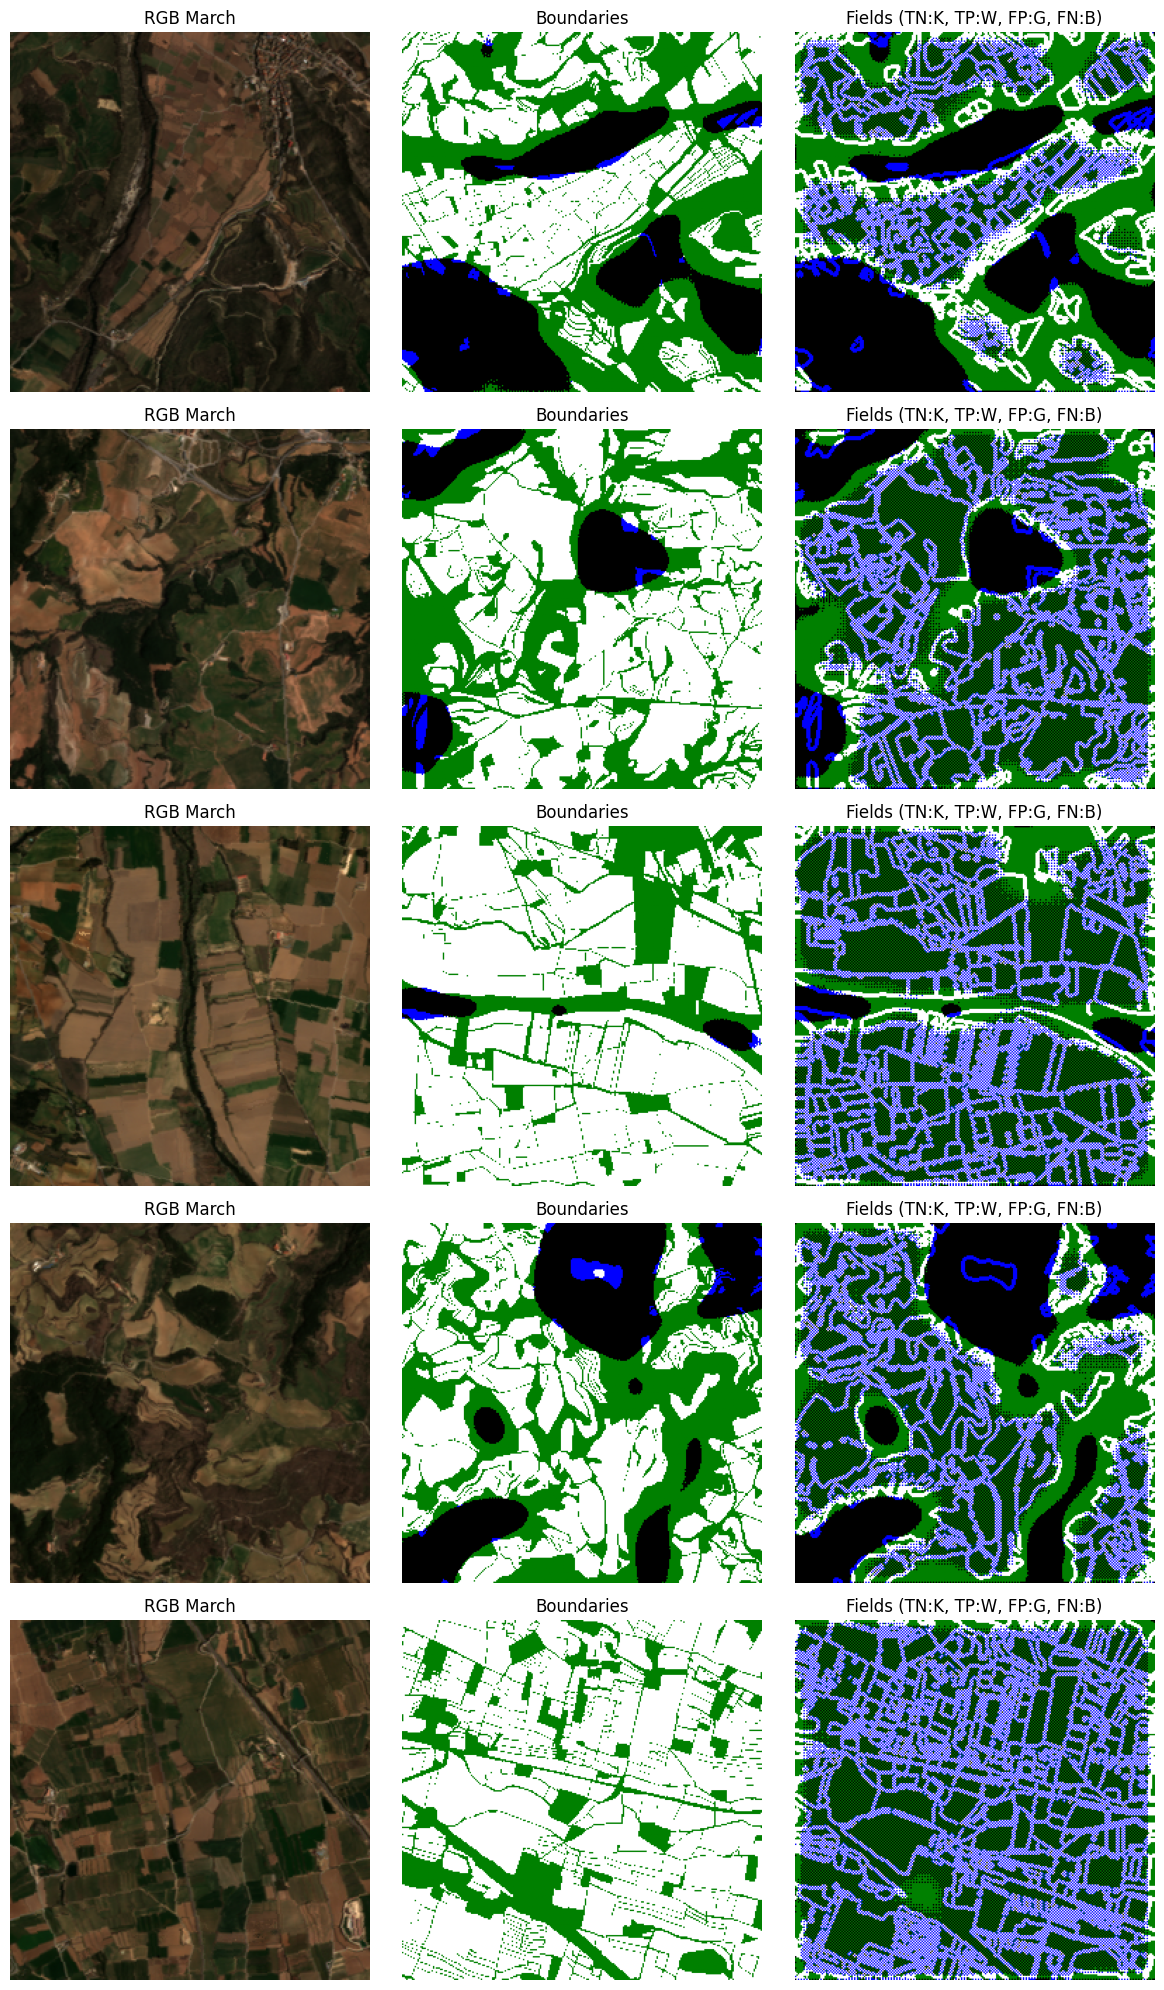

In [9]:
# Visualize random test samples
plot_random_n_chips_overlapped(model, config_path_yaml=CONFIG_PATH, n=5, split="test")